In [1]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pandas

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, random_split, Dataset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from IPython.display import FileLink, display

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True


In [2]:
DATASET_ROOT = "/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")

CONFIG = {
    "seed": 42,
    "image_size": 224,          # ConvNeXt-Tiny standard resolution
    "batch_size": 16,           # Kept identical to the other 4 models for a fair cross-model comparison
    "accum_steps": 2,           # Effective batch size of 32 (16 x 2) - same as the other runs
    "num_workers": 2,
    "num_epochs": 100,
    "learning_rate": 1e-4,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

raw_train = datasets.ImageFolder(TRAIN_DIR)
raw_val = datasets.ImageFolder(VAL_DIR)
full_dataset = ConcatDataset([raw_train, raw_val])

CLASS_TO_IDX = raw_train.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

total_len = len(full_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(CONFIG["seed"])
)

class TransformWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_dataset = TransformWrapper(train_subset, transform=train_transforms)
val_dataset = TransformWrapper(val_subset, transform=val_test_transforms)
test_dataset = TransformWrapper(test_subset, transform=val_test_transforms)

print(f"Total images: {total_len}")
print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)} | Test images: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)

Total images: 5000
Train images: 3500 | Val images: 750 | Test images: 750


In [4]:
def build_convnext_model(num_classes=2):
    model = models.convnext_tiny(weights=None)

    # ConvNeXt stores its final classification layer inside model.classifier[2]
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)

    return model

model = build_convnext_model(num_classes=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ConvNeXt-Tiny ready on {DEVICE}. Trainable parameters: {num_trainable:,}")

ConvNeXt-Tiny ready on cuda. Trainable parameters: 27,821,666


In [5]:
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
CHECKPOINT_PATH = "/kaggle/working/checkpoints/convnext_tiny_best.pth"

best_val_loss = float("inf")
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
start_time = time.time()

for epoch in range(1, CONFIG["num_epochs"] + 1):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    optimizer.zero_grad()

    for step, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels) / CONFIG["accum_steps"]
        loss.backward()

        if (step + 1) % CONFIG["accum_steps"] == 0 or (step + 1) == len(train_loader):
            optimizer.step()
            optimizer.zero_grad()

        running_loss += loss.item() * CONFIG["accum_steps"] * images.size(0)
        running_correct += (outputs.argmax(dim=1) == labels).sum().item()
        running_total += images.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += images.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:03d}/{CONFIG['num_epochs']} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed/60:.1f} min. Best val_loss: {best_val_loss:.4f}")
print(f"Best checkpoint saved to {CHECKPOINT_PATH}")

# Reload the best checkpoint (not just whatever the last epoch left in memory) before evaluation
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

Epoch 001/100 | train_loss=0.7147 train_acc=0.5549 | val_loss=0.6879 val_acc=0.5667
Epoch 002/100 | train_loss=0.5882 train_acc=0.6823 | val_loss=0.5770 val_acc=0.6867
Epoch 003/100 | train_loss=0.5535 train_acc=0.7157 | val_loss=0.5853 val_acc=0.6920
Epoch 004/100 | train_loss=0.5133 train_acc=0.7509 | val_loss=0.5296 val_acc=0.7520
Epoch 005/100 | train_loss=0.4884 train_acc=0.7660 | val_loss=0.5347 val_acc=0.7400
Epoch 006/100 | train_loss=0.4894 train_acc=0.7531 | val_loss=0.5411 val_acc=0.7173
Epoch 007/100 | train_loss=0.4437 train_acc=0.7843 | val_loss=0.5240 val_acc=0.7467
Epoch 008/100 | train_loss=0.4341 train_acc=0.7891 | val_loss=0.4992 val_acc=0.7507
Epoch 009/100 | train_loss=0.4266 train_acc=0.7966 | val_loss=0.4788 val_acc=0.7707
Epoch 010/100 | train_loss=0.4017 train_acc=0.8137 | val_loss=0.5193 val_acc=0.7427
Epoch 011/100 | train_loss=0.4037 train_acc=0.8120 | val_loss=0.4956 val_acc=0.7480
Epoch 012/100 | train_loss=0.3706 train_acc=0.8297 | val_loss=0.4568 val_acc

<All keys matched successfully>

===== Classification Report (Test Set) =====
              precision    recall  f1-score   support

          ai       0.79      0.80      0.79       370
      nature       0.80      0.79      0.80       380

    accuracy                           0.79       750
   macro avg       0.79      0.79      0.79       750
weighted avg       0.79      0.79      0.79       750



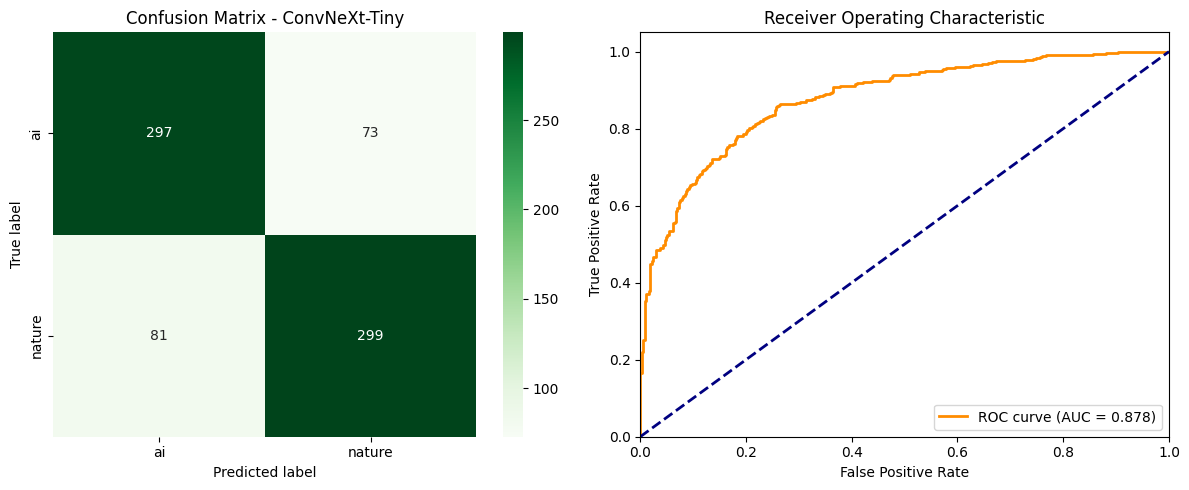

In [6]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().tolist()
        preds = outputs.argmax(dim=1).cpu().tolist()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

print("===== Classification Report (Test Set) =====")
print(classification_report(all_labels, all_preds, target_names=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]],
            yticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]], ax=axes[0])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Confusion Matrix - ConvNeXt-Tiny")

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [7]:
output_dir = "/kaggle/working/results"
os.makedirs(output_dir, exist_ok=True)

acc = accuracy_score(all_labels, all_preds)
pos_lbl = CLASS_TO_IDX.get("ai", 0)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=pos_lbl
)

results_row = {
    "dataset": "tiny_genimage_wukong",
    "model": "convnext_tiny",
    "num_epochs": CONFIG["num_epochs"],
    "train_images": len(train_dataset),
    "test_images": len(test_dataset),
    "test_accuracy": round(acc, 4),
    "test_precision": round(precision, 4),
    "test_recall": round(recall, 4),
    "test_f1_score": round(f1, 4),
    "test_auc": round(roc_auc, 4)
}

results_df = pd.DataFrame([results_row])
display(results_df)

RESULTS_CSV_PATH = os.path.join(output_dir, "convnext_tiny_test_results.csv")
results_df.to_csv(RESULTS_CSV_PATH, index=False)

FINAL_MODEL_PATH = os.path.join(output_dir, "convnext_tiny_best_model.pth")
shutil.copy(CHECKPOINT_PATH, FINAL_MODEL_PATH)

print("\n===== Download Links =====")
display(FileLink(RESULTS_CSV_PATH))
display(FileLink(FINAL_MODEL_PATH))

,dataset,model,num_epochs,train_images,test_images,test_accuracy,test_precision,test_recall,test_f1_score,test_auc
0,tiny_genimage_wukong,convnext_tiny,100,3500,750,0.7947,0.7857,0.8027,0.7941,0.8782



===== Download Links =====


/kaggle/working/results/convnext_tiny_test_results.csv

/kaggle/working/results/convnext_tiny_best_model.pth